
# Stock Market Price Movement Prediction

This notebook follows the formal project flow from `Objective.md`:
1. Data Collection and Exploration
2. Data Cleaning and Transformation
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Model Development
6. Model Evaluation and Hyperparameter Tuning
7. Model Saving for Streamlit Deployment


In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

BASE_DIR = Path.cwd()
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA", "JPM", "V", "JNJ"]
START_DATE = (pd.Timestamp.today() - pd.Timedelta(days=4200)).strftime("%Y-%m-%d")
ENABLE_GPU = True  # Optional: use GPU for XGBoost if CUDA is available

print("Start date:", START_DATE)


Start date: 2014-10-13


In [2]:
def get_xgb_candidate(enable_gpu: bool = True):
    """Return (name, model) for XGBoost, preferring GPU when available."""
    try:
        from xgboost import XGBClassifier
    except Exception:
        return None

    params = dict(
        n_estimators=700,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )

    if enable_gpu:
        params["device"] = "cuda"
        return ("XGBoost (GPU preferred)", XGBClassifier(**params))

    return ("XGBoost (CPU)", XGBClassifier(**params))


## Step 1 - Data Collection and Initial Exploration

In [3]:

def normalize_downloaded_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [str(col[0]).strip() for col in df.columns.to_flat_index()]
    else:
        df.columns = [str(col).strip() for col in df.columns]
    return df.rename(columns={"Date_": "Date", "Adj Close": "Adj_Close"})


def download_one_ticker(ticker: str, start_date: str) -> pd.DataFrame:
    data = yf.download(ticker, start=start_date, progress=False, auto_adjust=False).reset_index()
    data = normalize_downloaded_columns(data)
    if data.empty:
        raise ValueError(f"No data downloaded for {ticker}")
    data["Ticker"] = ticker
    return data


raw_parts = []
for t in TICKERS:
    try:
        raw_parts.append(download_one_ticker(t, START_DATE))
    except Exception as exc:
        print(f"Skipping {t}: {exc}")

raw_df = pd.concat(raw_parts, ignore_index=True).sort_values(["Ticker", "Date"]).reset_index(drop=True)
print("Raw shape:", raw_df.shape)
raw_df.head()


Raw shape: (28900, 8)


,Date,Adj_Close,Close,High,Low,Open,Volume,Ticker
0,2014-10-13,22.010916,24.952499,25.445000,24.952499,25.332500,214333600,AAPL
1,2014-10-14,21.777155,24.687500,25.129999,24.642500,25.097500,254754400,AAPL
2,2014-10-15,21.510317,24.385000,24.787500,23.795000,24.492500,403734400,AAPL
3,2014-10-16,21.228043,24.065001,24.430000,23.852501,23.887501,288618000,AAPL
4,2014-10-17,21.538986,24.417500,24.750000,24.202499,24.375000,272718800,AAPL


In [4]:

raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28900 entries, 0 to 28899
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       28900 non-null  datetime64[ns]
 1   Adj_Close  28900 non-null  float64       
 2   Close      28900 non-null  float64       
 3   High       28900 non-null  float64       
 4   Low        28900 non-null  float64       
 5   Open       28900 non-null  float64       
 6   Volume     28900 non-null  int64         
 7   Ticker     28900 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 1.8+ MB


In [5]:

raw_df.describe(include='all').T.head(12)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,28900,NaN,NaN,NaN,2020-07-09 07:50:51.903114240,2014-10-13 00:00:00,2017-08-24 00:00:00,2020-07-09 12:00:00,2023-05-23 00:00:00,2026-04-10 00:00:00,NaN
Adj_Close,28900.0,NaN,NaN,NaN,139.605451,0.40115,50.090078,116.515724,188.510986,788.148987,118.465834
Close,28900.0,NaN,NaN,NaN,144.631386,0.41975,55.93075,128.070007,191.349998,790.0,118.325482
High,28900.0,NaN,NaN,NaN,146.26252,0.4325,56.583626,129.439995,193.897499,796.25,119.771327
Low,28900.0,NaN,NaN,NaN,142.909755,0.41925,55.346249,126.634998,188.827507,780.820007,116.854801
Open,28900.0,NaN,NaN,NaN,144.608711,0.42325,55.937583,128.025002,191.402496,791.150024,118.370843
Volume,28900.0,NaN,NaN,NaN,84442023.66436,1640900.0,12134625.0,30315000.0,82605975.0,3692928000.0,150599424.850465
Ticker,28900,10,AAPL,2890,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 2 - Data Cleaning and Transformation

In [6]:

clean_df = raw_df.copy()

# Basic numeric cleanup
num_cols = ["Open", "High", "Low", "Close", "Adj_Close", "Volume"]
for c in num_cols:
    clean_df[c] = pd.to_numeric(clean_df[c], errors="coerce")

# Missing value handling inside each ticker time series
clean_df = clean_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
clean_df[num_cols] = clean_df.groupby("Ticker")[num_cols].transform(lambda x: x.ffill().bfill())

# Remove rows that still have essential missing values
clean_df = clean_df.dropna(subset=["Date", "Open", "High", "Low", "Close", "Volume"]).reset_index(drop=True)

print("Clean shape:", clean_df.shape)
print("Missing values after cleaning:")
print(clean_df.isna().sum().sort_values(ascending=False).head(10))

# Export cleaned dataset for tabular/reporting tools
clean_df.to_csv(BASE_DIR / "cleaned_stock_data.csv", index=False)
print("Saved cleaned_stock_data.csv")


Clean shape: (28900, 8)
Missing values after cleaning:
Date         0
Adj_Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Ticker       0
dtype: int64
Saved cleaned_stock_data.csv


## Step 3 - Exploratory Data Analysis (EDA)

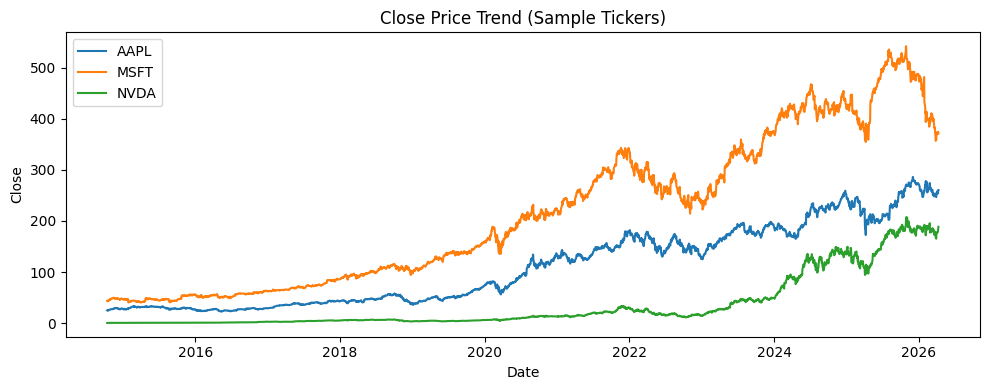

In [7]:
plt.figure(figsize=(10, 4))
for t in ["AAPL", "MSFT", "NVDA"]:
    subset = clean_df[clean_df["Ticker"] == t]
    plt.plot(subset["Date"], subset["Close"], label=t)
plt.title("Close Price Trend (Sample Tickers)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.tight_layout()
plt.show()


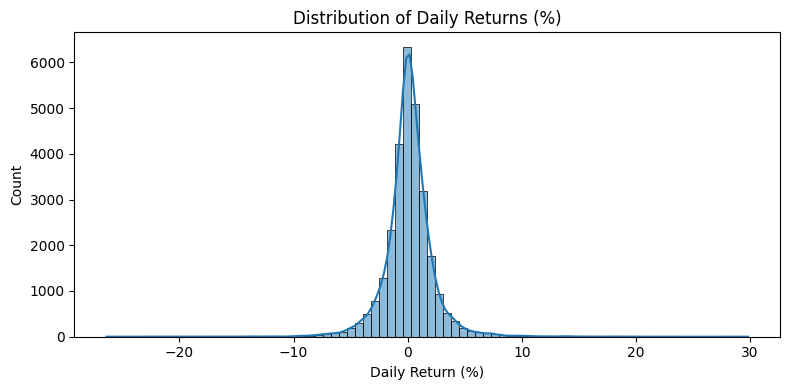

In [8]:
eda_df = clean_df.copy()
eda_df["Daily_Return"] = eda_df.groupby("Ticker")["Close"].pct_change() * 100

plt.figure(figsize=(8, 4))
sns.histplot(eda_df["Daily_Return"].dropna(), bins=80, kde=True)
plt.title("Distribution of Daily Returns (%)")
plt.xlabel("Daily Return (%)")
plt.tight_layout()
plt.show()


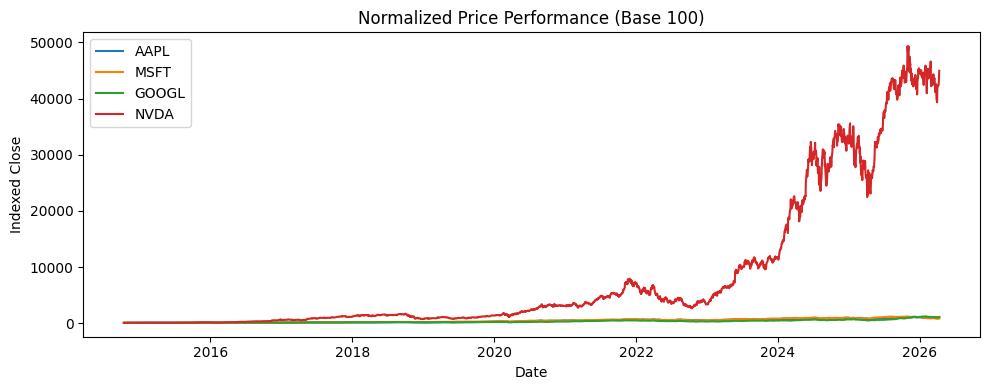

In [9]:
# Normalized performance comparison (base = 100)
plt.figure(figsize=(10, 4))
for t in ["AAPL", "MSFT", "GOOGL", "NVDA"]:
    s = clean_df[clean_df["Ticker"] == t].copy()
    s = s.sort_values("Date")
    s["Indexed_Close"] = (s["Close"] / s["Close"].iloc[0]) * 100
    plt.plot(s["Date"], s["Indexed_Close"], label=t)

plt.title("Normalized Price Performance (Base 100)")
plt.xlabel("Date")
plt.ylabel("Indexed Close")
plt.legend()
plt.tight_layout()
plt.show()


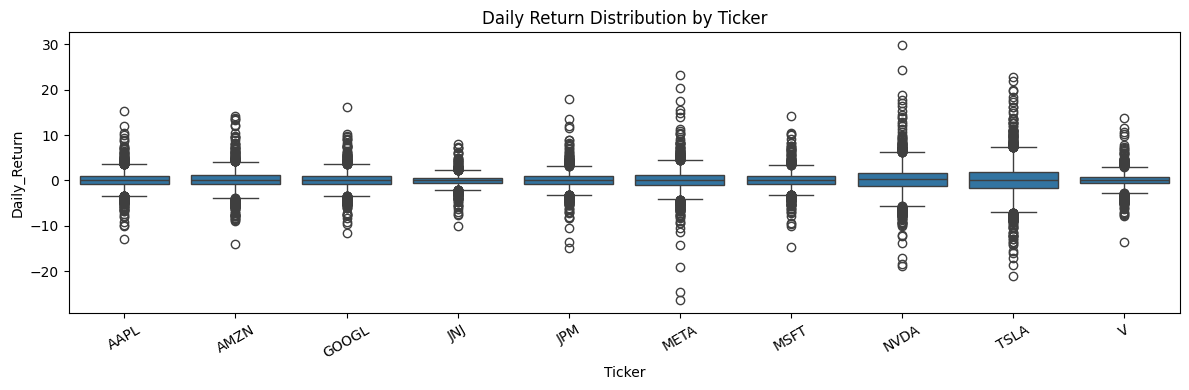

In [10]:
# Daily return boxplot by ticker
box_df = eda_df.dropna(subset=["Daily_Return"]).copy()
plt.figure(figsize=(12, 4))
sns.boxplot(data=box_df, x="Ticker", y="Daily_Return")
plt.title("Daily Return Distribution by Ticker")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


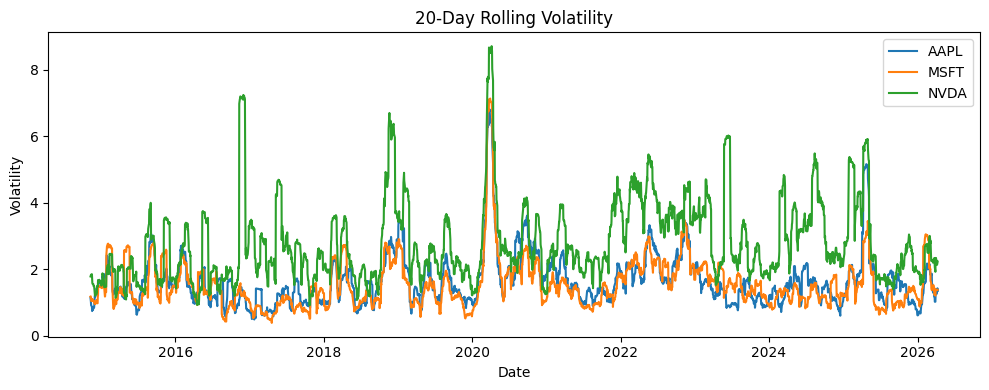

In [11]:
# Rolling volatility (20-day)
vol_df = eda_df.copy()
vol_df["Volatility_20"] = vol_df.groupby("Ticker")["Daily_Return"].transform(lambda x: x.rolling(20).std())

plt.figure(figsize=(10, 4))
for t in ["AAPL", "MSFT", "NVDA"]:
    s = vol_df[vol_df["Ticker"] == t]
    plt.plot(s["Date"], s["Volatility_20"], label=t)

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.show()


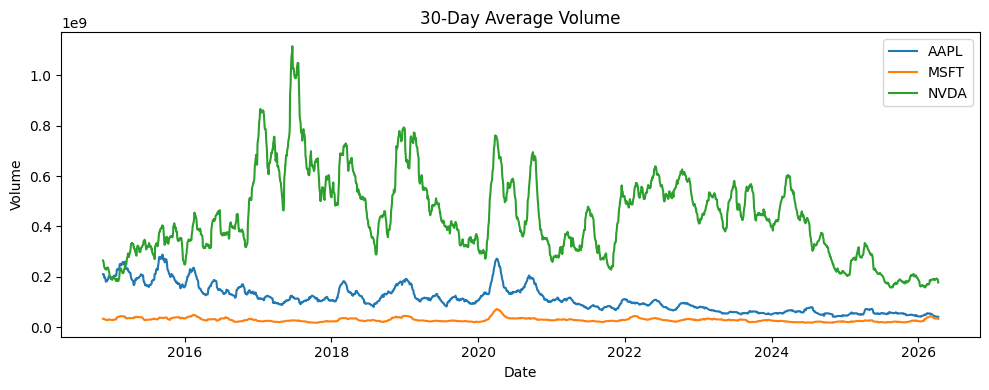

In [12]:
# Volume trend (30-day average)
volm_df = clean_df.copy()
volm_df["Volume_MA_30"] = volm_df.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(30).mean())

plt.figure(figsize=(10, 4))
for t in ["AAPL", "MSFT", "NVDA"]:
    s = volm_df[volm_df["Ticker"] == t]
    plt.plot(s["Date"], s["Volume_MA_30"], label=t)

plt.title("30-Day Average Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.show()


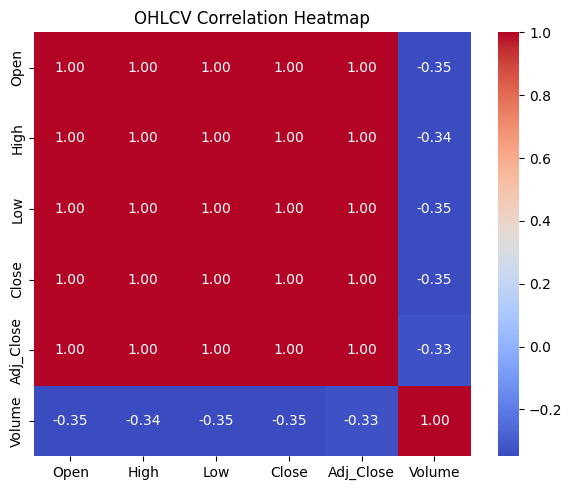

In [13]:
# Correlation heatmap of key market variables
corr_cols = ["Open", "High", "Low", "Close", "Adj_Close", "Volume"]
plt.figure(figsize=(6, 5))
sns.heatmap(clean_df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("OHLCV Correlation Heatmap")
plt.tight_layout()
plt.show()


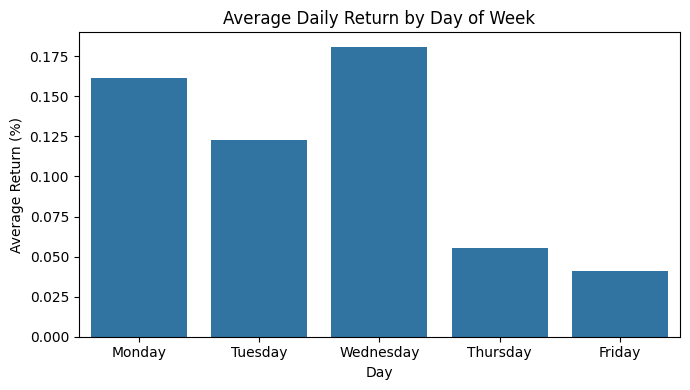

In [14]:
# Average return by day of week
dow_df = eda_df.dropna(subset=["Daily_Return"]).copy()
dow_df["DayName"] = dow_df["Date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

plt.figure(figsize=(7, 4))
sns.barplot(data=dow_df, x="DayName", y="Daily_Return", order=order, estimator="mean", errorbar=None)
plt.title("Average Daily Return by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Return (%)")
plt.tight_layout()
plt.show()


## Step 4 - Feature Engineering

In [15]:

def add_features(group: pd.DataFrame) -> pd.DataFrame:
    d = group.sort_values("Date").copy()

    d["Daily_Return"] = d["Close"].pct_change() * 100
    d["Gap_Open"] = ((d["Open"] - d["Close"].shift(1)) / d["Close"].shift(1)) * 100
    d["HL_Spread"] = ((d["High"] - d["Low"]) / d["Close"]) * 100
    d["Price_Range"] = ((d["High"] - d["Low"]) / d["Open"]) * 100

    d["Momentum_5"] = d["Close"] - d["Close"].shift(5)
    d["Momentum_10"] = d["Close"] - d["Close"].shift(10)
    d["Momentum_20"] = d["Close"] - d["Close"].shift(20)

    d["MA_5"] = d["Close"].rolling(5).mean()
    d["MA_10"] = d["Close"].rolling(10).mean()
    d["MA_20"] = d["Close"].rolling(20).mean()
    d["MA_50"] = d["Close"].rolling(50).mean()
    d["MA_Ratio_5_20"] = d["MA_5"] / d["MA_20"]
    d["MA_Ratio_10_50"] = d["MA_10"] / d["MA_50"]

    d["Ret_1"] = d["Close"].pct_change(1) * 100
    d["Ret_2"] = d["Close"].pct_change(2) * 100
    d["Ret_3"] = d["Close"].pct_change(3) * 100
    d["Ret_5"] = d["Close"].pct_change(5) * 100
    d["Ret_10"] = d["Close"].pct_change(10) * 100

    d["Volatility_5"] = d["Daily_Return"].rolling(5).std()
    d["Volatility_10"] = d["Daily_Return"].rolling(10).std()
    d["Volatility_20"] = d["Daily_Return"].rolling(20).std()

    d["Volume_MA_10"] = d["Volume"].rolling(10).mean()
    d["Volume_Ratio"] = d["Volume"] / d["Volume_MA_10"]
    d["Volume_Change"] = d["Volume"].pct_change() * 100

    delta = d["Close"].diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)
    rs = gains.rolling(14).mean() / losses.rolling(14).mean().replace(0, np.nan)
    d["RSI"] = 100 - (100 / (1 + rs))

    ema_12 = d["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = d["Close"].ewm(span=26, adjust=False).mean()
    d["MACD"] = ema_12 - ema_26
    d["MACD_Signal"] = d["MACD"].ewm(span=9, adjust=False).mean()
    d["MACD_Hist"] = d["MACD"] - d["MACD_Signal"]

    m20 = d["Close"].rolling(20).mean()
    s20 = d["Close"].rolling(20).std()
    d["BB_Upper"] = m20 + 2 * s20
    d["BB_Lower"] = m20 - 2 * s20
    d["BB_Width"] = d["BB_Upper"] - d["BB_Lower"]
    d["BB_PctB"] = (d["Close"] - d["BB_Lower"]) / (d["BB_Upper"] - d["BB_Lower"])

    tr1 = (d["High"] - d["Low"]).abs()
    tr2 = (d["High"] - d["Close"].shift(1)).abs()
    tr3 = (d["Low"] - d["Close"].shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    d["ATR_14"] = true_range.rolling(14).mean()

    d["Day_Of_Week"] = d["Date"].dt.dayofweek.astype(float)
    return d

feature_df = clean_df.groupby("Ticker", group_keys=False).apply(add_features).reset_index(drop=True)
print("Feature dataframe shape:", feature_df.shape)
feature_df.head()


Feature dataframe shape: (28900, 42)


,Date,Adj_Close,Close,High,Low,Open,Volume,Ticker,Daily_Return,Gap_Open,HL_Spread,Price_Range,Momentum_5,Momentum_10,Momentum_20,MA_5,MA_10,MA_20,MA_50,MA_Ratio_5_20,MA_Ratio_10_50,Ret_1,Ret_2,Ret_3,Ret_5,Ret_10,Volatility_5,Volatility_10,Volatility_20,Volume_MA_10,Volume_Ratio,Volume_Change,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Lower,BB_Width,BB_PctB,ATR_14,Day_Of_Week
0,2014-10-13,22.010916,24.952499,25.445000,24.952499,25.332500,214333600,AAPL,NaN,NaN,1.973751,1.944144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0
1,2014-10-14,21.777155,24.687500,25.129999,24.642500,25.097500,254754400,AAPL,-1.062015,0.581106,1.974680,1.942422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.062015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.858826,NaN,-0.021140,-0.004228,-0.016912,NaN,NaN,NaN,NaN,NaN,1.0
2,2014-10-15,21.510317,24.385000,24.787500,23.795000,24.492500,403734400,AAPL,-1.225316,-0.789872,4.070126,4.052262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.225316,-2.274318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.479854,NaN,-0.061592,-0.015701,-0.045891,NaN,NaN,NaN,NaN,NaN,2.0
3,2014-10-16,21.228043,24.065001,24.430000,23.852501,23.887501,288618000,AAPL,-1.312281,-2.040186,2.399748,2.417580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.312281,-2.521517,-3.556753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-28.512904,NaN,-0.118111,-0.036183,-0.081928,NaN,NaN,NaN,NaN,NaN,3.0
4,2014-10-17,21.538986,24.417500,24.750000,24.202499,24.375000,272718800,AAPL,1.464779,1.288176,2.242247,2.246156,NaN,NaN,NaN,24.5015,NaN,NaN,NaN,NaN,NaN,1.464779,0.133276,-1.093673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.508735,NaN,-0.132926,-0.055531,-0.077395,NaN,NaN,NaN,NaN,NaN,4.0


## Step 5 - Feature Selection

In [16]:

def build_model_table(horizon_steps: int) -> pd.DataFrame:
    d = feature_df.copy()
    d["Future_Close"] = d.groupby("Ticker")["Close"].shift(-horizon_steps)
    d["Target"] = ((d["Future_Close"] - d["Close"]) / d["Close"] > 0).astype(int)
    d = d.dropna().reset_index(drop=True)
    return d


def get_candidate_features(df: pd.DataFrame) -> list[str]:
    exclude = {"Date", "Ticker", "Future_Close", "Target", "Adj_Close"}
    return [c for c in df.columns if c not in exclude]


def prune_correlated_features(x: pd.DataFrame, threshold: float = 0.98) -> tuple[pd.DataFrame, list[str]]:
    corr = x.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]
    return x.drop(columns=drop_cols, errors="ignore"), drop_cols


## Step 6 - Model Development (Baselines + Candidates)

In [17]:
def time_split_xy(
    df: pd.DataFrame,
    feature_cols: list[str],
    val_ratio_within_train: float = 0.25,
    test_ratio: float = 0.20,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    df = df.sort_values("Date").reset_index(drop=True)

    if not (0.0 < test_ratio < 0.5):
        raise ValueError("test_ratio must be between 0 and 0.5.")
    if not (0.0 < val_ratio_within_train < 0.5):
        raise ValueError("val_ratio_within_train must be between 0 and 0.5.")

    x = df[feature_cols].replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0.0).astype(float)
    y = df["Target"].astype(int)

    n_rows = len(df)
    test_start = int(n_rows * (1.0 - test_ratio))
    test_start = min(max(test_start, 2), n_rows - 1)

    train_val_rows = test_start
    val_start = int(train_val_rows * (1.0 - val_ratio_within_train))
    val_start = min(max(val_start, 1), train_val_rows - 1)

    x_train, x_val, x_test = x.iloc[:val_start], x.iloc[val_start:test_start], x.iloc[test_start:]
    y_train, y_val, y_test = y.iloc[:val_start], y.iloc[val_start:test_start], y.iloc[test_start:]

    if min(len(x_train), len(x_val), len(x_test)) == 0:
        raise ValueError("Not enough rows for chronological train/validation/test split.")

    return x_train, x_val, x_test, y_train, y_val, y_test


def best_accuracy_threshold(y_true: np.ndarray, probs: np.ndarray) -> tuple[float, float]:
    best_t, best_acc = 0.5, -1
    for t in np.linspace(0.30, 0.70, 81):
        pred = (probs >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_t, best_acc = float(t), float(acc)
    return best_t, best_acc


def _count_search_space(param_dist: dict[str, list]) -> int:
    total = 1
    for values in param_dist.values():
        total *= max(len(values), 1)
    return int(total)


def evaluate_candidates(x_train, x_val, y_train, y_val, enable_gpu: bool = True):
    scaler = StandardScaler()
    x_train_s = scaler.fit_transform(x_train)
    x_val_s = scaler.transform(x_val)

    candidate_configs = {
        "LogisticRegression": {
            "estimator": LogisticRegression(max_iter=4000, class_weight="balanced", solver="liblinear", random_state=42),
            "param_distributions": {
                "C": [0.01, 0.03, 0.08, 0.15, 0.3, 0.6, 1.0],
            },
            "n_iter": 7,
        },
        "RandomForest": {
            "estimator": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
            "param_distributions": {
                "n_estimators": [400, 800, 1200],
                "max_depth": [8, 12, 16],
                "min_samples_leaf": [2, 4, 6],
                "min_samples_split": [2, 4, 8],
            },
            "n_iter": 12,
        },
        "ExtraTrees": {
            "estimator": ExtraTreesClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
            "param_distributions": {
                "n_estimators": [400, 800, 1200],
                "max_depth": [8, 12, 16],
                "min_samples_leaf": [2, 4, 6],
                "min_samples_split": [2, 4, 8],
            },
            "n_iter": 12,
        },
        "GradientBoosting": {
            "estimator": GradientBoostingClassifier(random_state=42),
            "param_distributions": {
                "n_estimators": [150, 250, 400],
                "learning_rate": [0.01, 0.02, 0.05],
                "max_depth": [2, 3, 4],
                "subsample": [0.8, 0.9, 1.0],
            },
            "n_iter": 12,
        },
    }

    xgb_candidate = get_xgb_candidate(enable_gpu)
    if xgb_candidate is not None:
        xgb_name, xgb_model = xgb_candidate
        candidate_configs[xgb_name] = {
            "estimator": xgb_model,
            "param_distributions": {
                "n_estimators": [300, 500, 700],
                "max_depth": [4, 6, 8],
                "learning_rate": [0.02, 0.03, 0.05],
                "subsample": [0.8, 0.9, 1.0],
                "colsample_bytree": [0.8, 0.9, 1.0],
            },
            "n_iter": 10,
        }

    n_splits = min(5, max(2, len(x_train) // 120))
    if n_splits >= len(x_train):
        n_splits = max(2, len(x_train) - 1)
    if n_splits < 2:
        raise ValueError("Not enough training rows for TimeSeriesSplit.")

    tscv = TimeSeriesSplit(n_splits=n_splits)

    rows = []
    trained = {}

    for name, cfg in candidate_configs.items():
        estimator = cfg["estimator"]
        param_dist = cfg["param_distributions"]
        prefixed_param_dist = {f"model__{k}": v for k, v in param_dist.items()}
        search_space = _count_search_space(param_dist)
        n_iter = min(int(cfg["n_iter"]), search_space)

        try:
            search = RandomizedSearchCV(
                estimator=Pipeline([("scaler", StandardScaler()), ("model", estimator)]),
                param_distributions=prefixed_param_dist,
                n_iter=n_iter,
                scoring="f1",
                cv=tscv,
                random_state=42,
                n_jobs=-1,
                refit=True,
            )
            search.fit(x_train, y_train)

            best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
            tuned_model = clone(estimator).set_params(**best_params)
            tuned_model.fit(x_train_s, y_train)

            probs = tuned_model.predict_proba(x_val_s)[:, 1]
            threshold, _ = best_accuracy_threshold(y_val.values, probs)
            pred = (probs >= threshold).astype(int)

            rows.append({
                "model": name,
                "cv_f1": float(search.best_score_),
                "val_accuracy": float(accuracy_score(y_val, pred)),
                "val_precision": float(precision_score(y_val, pred, zero_division=0)),
                "val_recall": float(recall_score(y_val, pred, zero_division=0)),
                "val_f1": float(f1_score(y_val, pred, zero_division=0)),
                "val_roc_auc": float(roc_auc_score(y_val, probs)),
                "threshold": float(threshold),
                "search_iterations": int(n_iter),
                "best_params": best_params,
            })
            trained[name] = tuned_model
        except Exception as exc:
            print(f"Skipping {name}: {exc}")

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        raise ValueError("No candidate models were successfully trained.")

    result_df = result_df.sort_values(["val_f1", "val_roc_auc", "cv_f1"], ascending=False).reset_index(drop=True)
    return scaler, trained, result_df, n_splits


## Step 7 - Model Evaluation and Hyperparameter/Tuning Strategy

In [18]:
def train_horizon(horizon_steps: int, horizon_label: str, enable_gpu: bool = True):
    data_h = build_model_table(horizon_steps)
    candidate_features = get_candidate_features(data_h)

    x_train_raw, x_val_raw, x_test_raw, y_train, y_val, y_test = time_split_xy(
        data_h, candidate_features, val_ratio_within_train=0.25, test_ratio=0.20
    )

    x_train_pruned, dropped = prune_correlated_features(x_train_raw, threshold=0.98)
    selected_features = list(x_train_pruned.columns)

    x_train = x_train_pruned
    x_val = x_val_raw.reindex(columns=selected_features).ffill().bfill().fillna(0.0).astype(float)
    x_test = x_test_raw.reindex(columns=selected_features).ffill().bfill().fillna(0.0).astype(float)

    scaler, trained_models, leaderboard, cv_splits = evaluate_candidates(
        x_train, x_val, y_train, y_val, enable_gpu=enable_gpu
    )
    best_row = leaderboard.iloc[0]
    best_name = best_row["model"]
    best_threshold = float(best_row["threshold"])
    best_model = trained_models[best_name]

    x_test_s = scaler.transform(x_test)
    probs = best_model.predict_proba(x_test_s)[:, 1]
    pred = (probs >= best_threshold).astype(int)

    test_metrics = {
        "accuracy": float(accuracy_score(y_test, pred)),
        "precision": float(precision_score(y_test, pred, zero_division=0)),
        "recall": float(recall_score(y_test, pred, zero_division=0)),
        "f1_score": float(f1_score(y_test, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test, probs)),
    }

    info = {
        "project_title": "Stock Market Price Movement Prediction",
        "horizon": horizon_label,
        "model_name": f"Optimized {best_name}",
        "training_tickers": TICKERS,
        "feature_count": len(selected_features),
        "features": selected_features,
        "decision_threshold": best_threshold,
        "model_selection_metric": "Validation F1 (tie-breaker: Validation ROC_AUC, CV F1)",
        "hyperparameter_search": "RandomizedSearchCV",
        "cv_strategy": f"TimeSeriesSplit(n_splits={cv_splits})",
        "split_strategy": "Chronological split: 60% train, 20% validation, 20% test",
        "train_rows": int(len(x_train)),
        "validation_rows": int(len(x_val)),
        "test_rows": int(len(x_test)),
        "trained_at": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
        "dropped_correlated_features": dropped,
        "candidate_results": leaderboard.to_dict(orient="records"),
        "best_params": best_row["best_params"],
        "validation_metrics": {
            "cv_f1": float(best_row["cv_f1"]),
            "accuracy": float(best_row["val_accuracy"]),
            "precision": float(best_row["val_precision"]),
            "recall": float(best_row["val_recall"]),
            "f1_score": float(best_row["val_f1"]),
            "roc_auc": float(best_row["val_roc_auc"]),
        },
        "gpu_enabled": bool(enable_gpu),
        **test_metrics,
    }

    print(f"\n===== {horizon_label} Results =====")
    display(leaderboard[["model", "cv_f1", "val_f1", "val_roc_auc", "threshold"]])
    print("Best model:", info["model_name"])
    print("Threshold tuned on validation split only.")
    print("Confusion matrix (test holdout):")
    print(confusion_matrix(y_test, pred))
    print("\nClassification report (test holdout):")
    print(classification_report(y_test, pred, digits=4))

    return best_model, scaler, selected_features, info


In [19]:
daily_model, daily_scaler, daily_features, daily_info = train_horizon(1, "1d", enable_gpu=ENABLE_GPU)
weekly_model, weekly_scaler, weekly_features, weekly_info = train_horizon(5, "5d", enable_gpu=ENABLE_GPU)



===== 1d Results =====


,model,cv_f1,val_f1,val_roc_auc,threshold
0,LogisticRegression,0.526859,0.670769,0.491802,0.365
1,RandomForest,0.522287,0.670633,0.502546,0.390
2,GradientBoosting,0.598937,0.658431,0.493817,0.500
3,ExtraTrees,0.513249,0.636219,0.503389,0.465
4,XGBoost (GPU preferred),0.558609,0.631369,0.506367,0.465


Best model: Optimized LogisticRegression
Threshold tuned on validation split only.
Confusion matrix (test holdout):
[[  93 2534]
 [  82 2970]]

Classification report (test holdout):
              precision    recall  f1-score   support

           0     0.5314    0.0354    0.0664      2627
           1     0.5396    0.9731    0.6942      3052

    accuracy                         0.5394      5679
   macro avg     0.5355    0.5043    0.3803      5679
weighted avg     0.5358    0.5394    0.4038      5679


===== 5d Results =====


,model,cv_f1,val_f1,val_roc_auc,threshold
0,GradientBoosting,0.715056,0.689392,0.487993,0.300
1,LogisticRegression,0.519939,0.689357,0.494906,0.355
2,XGBoost (GPU preferred),0.622948,0.688876,0.493734,0.300
3,ExtraTrees,0.540653,0.684835,0.496789,0.355
4,RandomForest,0.584581,0.675033,0.496735,0.405


Best model: Optimized GradientBoosting
Threshold tuned on validation split only.
Confusion matrix (test holdout):
[[   0 2511]
 [   0 3160]]

Classification report (test holdout):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      2511
           1     0.5572    1.0000    0.7157      3160

    accuracy                         0.5572      5671
   macro avg     0.2786    0.5000    0.3578      5671
weighted avg     0.3105    0.5572    0.3988      5671



## Step 8 - Save Final Artifacts for Streamlit

In [20]:
joblib.dump(daily_model, BASE_DIR / "stock_prediction_model.pkl")
joblib.dump(daily_scaler, BASE_DIR / "scaler.pkl")
joblib.dump(daily_info, BASE_DIR / "model_info.pkl")

joblib.dump(weekly_model, BASE_DIR / "stock_prediction_model_weekly.pkl")
joblib.dump(weekly_scaler, BASE_DIR / "scaler_weekly.pkl")
joblib.dump(weekly_info, BASE_DIR / "model_info_weekly.pkl")

print("Saved all model artifacts for app.py")


Saved all model artifacts for app.py


## Step 9 - Final Summary

In [21]:
summary = pd.DataFrame([
    {
        "Horizon": "Next Day (1d)",
        "Model": daily_info["model_name"],
        "Accuracy": round(daily_info["accuracy"], 4),
        "F1": round(daily_info["f1_score"], 4),
        "ROC_AUC": round(daily_info["roc_auc"], 4),
        "Threshold": round(daily_info["decision_threshold"], 3),
        "Features": daily_info["feature_count"],
        "GPU Enabled": daily_info.get("gpu_enabled", False),
    },
    {
        "Horizon": "Next Week (5d)",
        "Model": weekly_info["model_name"],
        "Accuracy": round(weekly_info["accuracy"], 4),
        "F1": round(weekly_info["f1_score"], 4),
        "ROC_AUC": round(weekly_info["roc_auc"], 4),
        "Threshold": round(weekly_info["decision_threshold"], 3),
        "Features": weekly_info["feature_count"],
        "GPU Enabled": weekly_info.get("gpu_enabled", False),
    },
])
summary


,Horizon,Model,Accuracy,F1,ROC_AUC,Threshold,Features,GPU Enabled
0,Next Day (1d),Optimized LogisticRegression,0.5394,0.6942,0.5035,0.365,28,True
1,Next Week (5d),Optimized GradientBoosting,0.5572,0.7157,0.5127,0.300,28,True



### Streamlit Deployment Note

After running this notebook and saving artifacts, start the app:

```bash
streamlit run app.py
```

The app reads the saved artifacts and performs live inference on the latest Yahoo Finance data.
